In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("dataset.csv")

print(df.head())
print(df.info())
print(df.describe())

   ID    Name   Age  Gender Department   Salary  Experience         City
0   1    Amit  25.0    Male         IT  35000.0           2  Bhubaneswar
1   2   Priya  28.0  Female         HR  42000.0           4      Cuttack
2   3   Rahul  32.0    Male    Finance  55000.0           7  Bhubaneswar
3   4   Sneha  29.0  Female         IT  48000.0           5         Puri
4   5  Rakesh   NaN    Male         IT  40000.0           3      Cuttack
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          25 non-null     int64  
 1   Name        25 non-null     object 
 2   Age         24 non-null     float64
 3   Gender      25 non-null     object 
 4   Department  25 non-null     object 
 5   Salary      24 non-null     float64
 6   Experience  25 non-null     int64  
 7   City        25 non-null     object 
dtypes: float64(2), int64(2), object(4)
memory usa

In [3]:
print(df.isnull().sum())

ID            0
Name          0
Age           1
Gender        0
Department    0
Salary        1
Experience    0
City          0
dtype: int64


In [4]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [5]:
df.dropna(inplace=True)

In [6]:
print("Duplicates:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

Duplicates: 0


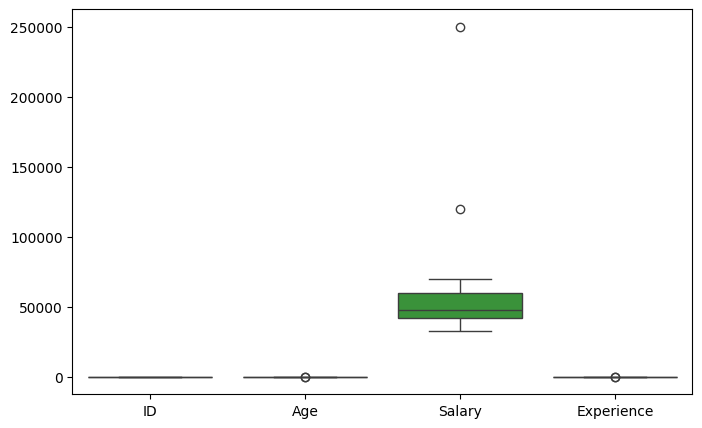

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df)
plt.show()

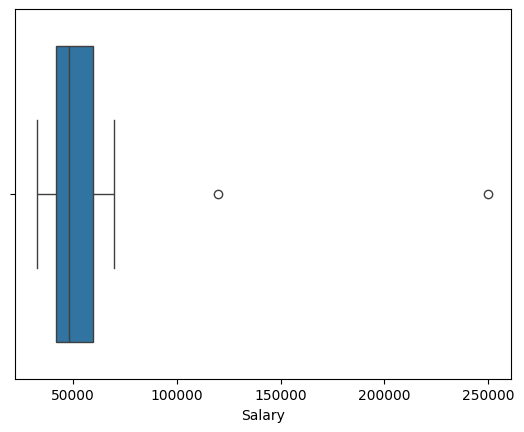

In [9]:
# Boxplot to visualize outliers
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["Salary"])
plt.show()

# Remove outliers from Salary only
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["Salary"] >= lower) & (df["Salary"] <= upper)]

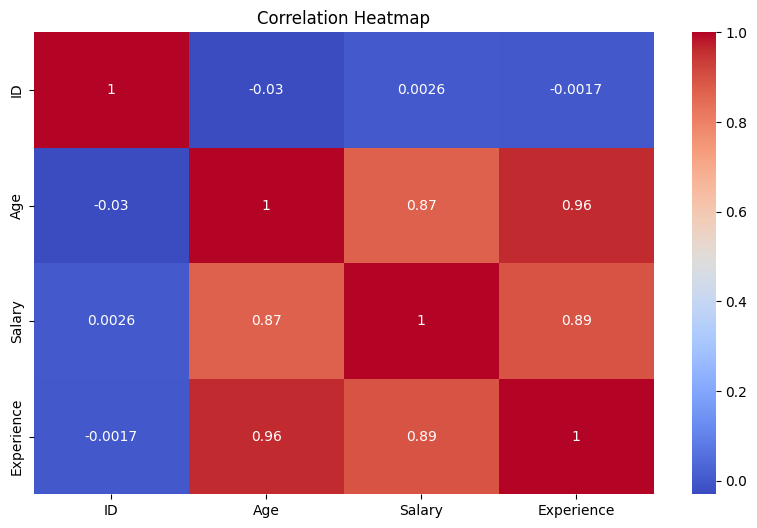

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

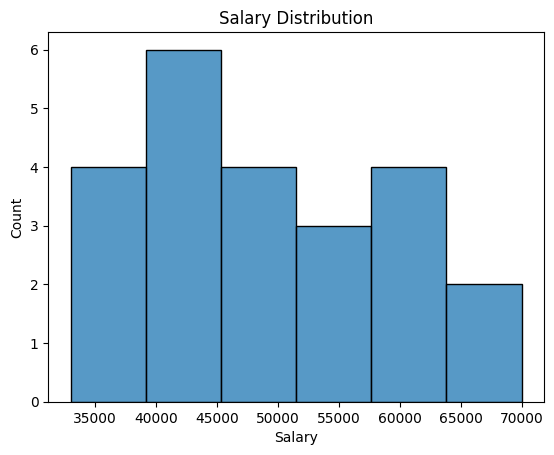

In [12]:
sns.histplot(df['Salary'])
plt.title("Salary Distribution")
plt.show()

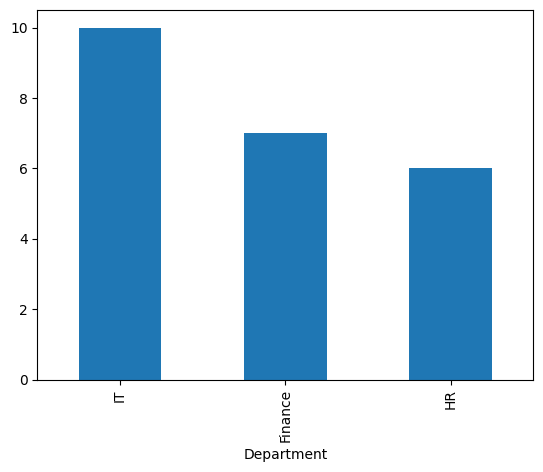

In [13]:
df['Department'].value_counts().plot(kind='bar')
plt.show()

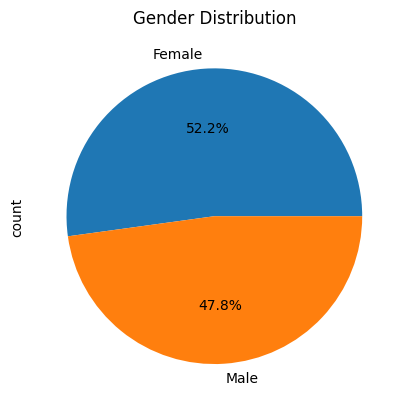

In [14]:
df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title("Gender Distribution")
plt.show()

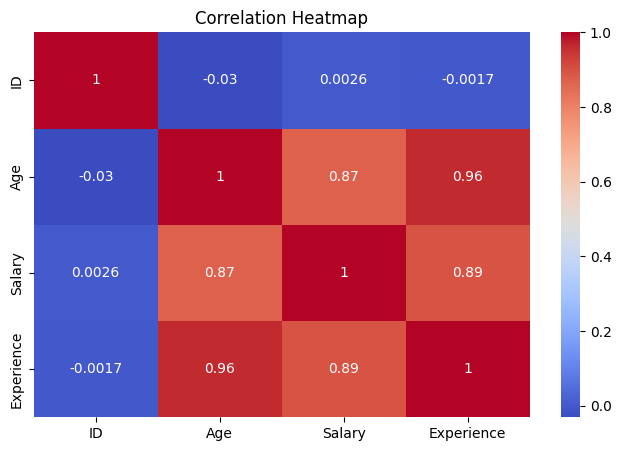

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [16]:
df.to_csv("cleaned_dataset.csv", index=False)